<a href="https://colab.research.google.com/github/KDB4926/gdg-5th-ai-mission/blob/%EA%B9%80%EB%8F%99%EB%B9%88/week3_mission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Week1_Misson_Course**


In [1]:
# 라이브러리 import 및 TensorFlow 버전 확인

import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
# 데이터 다운로드
path_to_train_file = tf.keras.utils.get_file(
    'train.txt',
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt'
)
path_to_test_file = tf.keras.utils.get_file(
    'test.txt',
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt'
)

14628807/14628807 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4893335/4893335 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# IN - 텍스트로 로드
path_to_train_file = tf.keras.utils.get_file(
    'train.txt',
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt'
)
path_to_test_file = tf.keras.utils.get_file(
    'test.txt',
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt'
)

train_text = open(path_to_train_file, 'rb').read().decode(encoding='utf-8')
test_text = open(path_to_test_file, 'rb').read().decode(encoding='utf-8')

print('Length of train text: {} characters'.format(len(train_text)))
print('Length of test text: {} characters'.format(len(test_text)))
print(train_text[:300])

Length of train text: 6937271 characters
Length of test text: 2318260 characters
id	document	label
9976970	아 더빙.. 진짜 짜증나네요 목소리	0
3819312	흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나	1
10265843	너무재밓었다그래서보는것을추천한다	0
9045019	교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정	0
6483659	사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다	1
5403919	막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.	0
7797314	원작의


In [4]:
# IN - Y(정답 라벨) 데이터 만들기
train_Y = np.array([
    [int(row.split('\t')[2])]
    for row in train_text.split('\n')[1:]
    if row.count('\t') > 0
])

test_Y = np.array([
    [int(row.split('\t')[2])]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
])

print("train_Y shape:", train_Y.shape)
print("test_Y shape:", test_Y.shape)
print("train_Y sample:", train_Y[:5])

train_Y shape: (150000, 1)
test_Y shape: (50000, 1)
train_Y sample: [[0]
 [1]
 [0]
 [0]
 [1]]


In [5]:
import re

def clean_str(string):
    string = re.sub(r"[^가-힣A-Za-z0-9(),!?\'\`]", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string)
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    string = re.sub(r"\'{2,}", "\'", string)
    string = re.sub(r"\'", "", string)

    return string.lower()

train_text_X = [row.split('\t')[1] for row in train_text.split('\n')[1:] if row.count('\t') > 0]
train_text_X = [clean_str(sentence) for sentence in train_text_X]
# 문장을 띄어쓰기 단위로 단어 분리
sentences = [sentence.split(' ') for sentence in train_text_X]
for i in range(5):
    print(sentences[i])

<>:13: SyntaxWarning: invalid escape sequence '\('
<>:14: SyntaxWarning: invalid escape sequence '\)'
<>:15: SyntaxWarning: invalid escape sequence '\?'
<>:13: SyntaxWarning: invalid escape sequence '\('
<>:14: SyntaxWarning: invalid escape sequence '\)'
<>:15: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipython-input-2842916861.py:13: SyntaxWarning: invalid escape sequence '\('
  string = re.sub(r"\(", " \( ", string)
/tmp/ipython-input-2842916861.py:14: SyntaxWarning: invalid escape sequence '\)'
  string = re.sub(r"\)", " \) ", string)
/tmp/ipython-input-2842916861.py:15: SyntaxWarning: invalid escape sequence '\?'
  string = re.sub(r"\?", " \? ", string)


['아', '더빙', '진짜', '짜증나네요', '목소리']
['흠', '포스터보고', '초딩영화줄', '오버연기조차', '가볍지', '않구나']
['너무재밓었다그래서보는것을추천한다']
['교도소', '이야기구먼', '솔직히', '재미는', '없다', '평점', '조정']
['사이몬페그의', '익살스런', '연기가', '돋보였던', '영화', '!', '스파이더맨에서', '늙어보이기만', '했던', '커스틴', '던스트가', '너무나도', '이뻐보였다']


In [6]:
VOCAB_SIZE = 2000   # 단어 사전 크기
MAX_LEN = 25        # 최대 문장 길이 (패딩 기준)

vectorize_layer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',  # 소문자 변환 + 구두점 제거
    split='whitespace',                         # 띄어쓰기 기준 토큰화
    max_tokens=VOCAB_SIZE,                      # 단어 사전 크기
    output_mode='int',                          # 정수 인코딩
    output_sequence_length=MAX_LEN              # 자동 패딩
)

vectorize_layer.adapt(train_text_X)  # 단어 사전 학습
# 텍스트를 정수 시퀀스로 변환 (패딩 포함)
train_X = vectorize_layer(train_text_X)

print(train_X[:5])

tf.Tensor(
[[  23  902    5    1 1097    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [ 586    1    1    1    1    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1   68  345   28   33    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1  102    1    2    1    1  844    1    1  570    1    0    0
     0    0    0    0    0    0    0    0    0    0    0]], shape=(5, 25), dtype=int64)


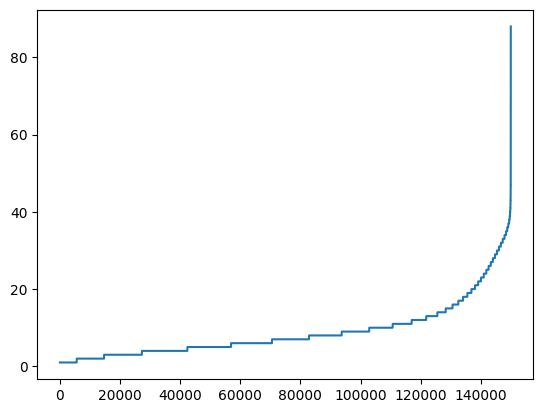

142587


In [7]:
import matplotlib.pyplot as plt
sentence_len = [len(sentence) for sentence in sentences]
sentence_len.sort()
plt.plot(sentence_len)
plt.show()

print(sum([int(l<=25) for l in sentence_len]))

# **Week2_Mission_Course**

In [8]:
test_text_X = [
    row.split('\t')[1]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
]

# Week1에서 학습된 vectorize_layer 그대로 사용합니다.
test_X = vectorize_layer(test_text_X)

print("test_X shape:", test_X.shape)
print("test_Y shape:", test_Y.shape)


test_X shape: (50000, 25)
test_Y shape: (50000, 1)


In [9]:
#모델의 주요 설정 값들을 미리 정의해줍니다.
VOCAB_SIZE = 2000
EMBEDDING_DIM = 128
MAX_LEN = 25
EPOCHS = 10
BATCH_SIZE = 32

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,321 (1.01 MB)

 Trainable params: 264,321 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [12]:
history = model.fit(
    train_X, train_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6698 - loss: 0.5678 - val_accuracy: 0.7469 - val_loss: 0.4788
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7532 - loss: 0.4624 - val_accuracy: 0.7582 - val_loss: 0.4590
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7544 - loss: 0.4558 - val_accuracy: 0.7585 - val_loss: 0.4550
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7582 - loss: 0.4474 - val_accuracy: 0.7515 - val_loss: 0.4605
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7554 - loss: 0.4488 - val_accuracy: 0.7610 - val_loss: 0.4573
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7597 - loss: 0.4440 - val_accuracy: 0.7399 - val_loss: 0.4722
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7605 - loss: 0.4389 - val_accuracy: 0.7552 - val_loss: 0.4597
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.7657 - loss: 0

In [13]:
test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4955, Test Accuracy: 0.7298


In [14]:
example_sentences = [
    "이 영화 진짜 재미있어요",
    "완전 지루하고 별로였음",
    "배우 연기는 좋았지만 스토리가 아쉬웠다"
]

example_seq = vectorize_layer(example_sentences)
pred = model.predict(example_seq)

for s, p in zip(example_sentences, pred):
    print(f"문장: {s}")
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
문장: 이 영화 진짜 재미있어요
긍정 확률: 0.9783
결과: 긍정 😊
문장: 완전 지루하고 별로였음
긍정 확률: 0.0113
결과: 부정 😞
문장: 배우 연기는 좋았지만 스토리가 아쉬웠다
긍정 확률: 0.0096
결과: 부정 😞


In [15]:
# 실습 미션 코드를 작성해주세요.
# 1. Epoch=30 으로 늘려 모델 학습
# 2. matplotlib를 이용하여 Epoch 10 과 Epoch 30을 비교하여 시각화
EPOCHS=30

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,321 (1.01 MB)

 Trainable params: 264,321 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [18]:
history = model.fit(
    train_X, train_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6703 - loss: 0.5650 - val_accuracy: 0.7548 - val_loss: 0.4615
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.7526 - loss: 0.4633 - val_accuracy: 0.7571 - val_loss: 0.4632
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7563 - loss: 0.4545 - val_accuracy: 0.7613 - val_loss: 0.4556
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.7567 - loss: 0.4493 - val_accuracy: 0.7459 - val_loss: 0.4662
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7582 - loss: 0.4461 - val_accuracy: 0.7583 - val_loss: 0.4576
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7599 - loss: 0.4415 - val_accuracy: 0.7591 - val_loss: 0.4582
Epoch 7/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7630 - loss: 0.4380 - val_accuracy: 0.7489 - val_loss: 0.4651
Epoch 8/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7662 - loss: 0

--- 10 에포크 모델 학습 시작 ---
--- 10 에포크 모델 학습 완료 ---
--- 30 에포크 모델 학습 시작 ---
Epoch 1/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.6723 - loss: 0.5655 - val_accuracy: 0.7593 - val_loss: 0.4632
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7531 - loss: 0.4631 - val_accuracy: 0.7622 - val_loss: 0.4570
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7539 - loss: 0.4545 - val_accuracy: 0.7564 - val_loss: 0.4596
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7561 - loss: 0.4496 - val_accuracy: 0.7602 - val_loss: 0.4557
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7579 - loss: 0.4464 - val_accuracy: 0.7596 - val_loss: 0.4580
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.7596 - loss: 0.4402 - val_accuracy: 0.7517 - val_loss: 0.4617
Epoch 7/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7610 - loss: 0.4391 - val_accuracy: 0.7629 - val_loss: 0.4571
Epoch 8/30


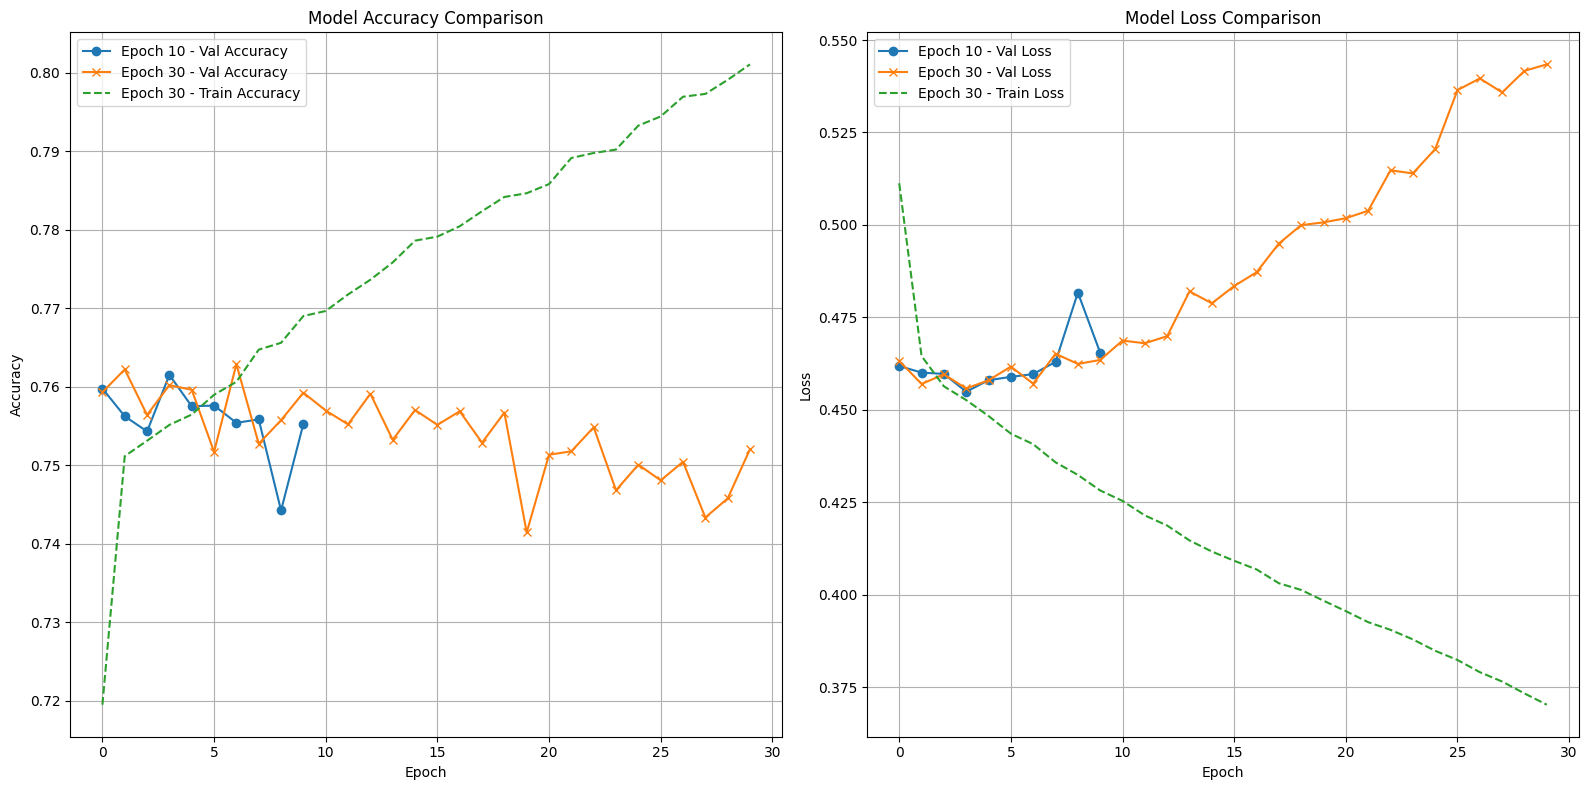

In [19]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# --- 1. Epoch 10 모델 학습 ---
# (이전 코드에서 이미 실행했지만, 비교를 위해 변수명을 지정하여 다시 실행)

print("--- 10 에포크 모델 학습 시작 ---")
# 모델 정의
model_10 = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 모델 컴파일
model_10.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

# 10 에포크 모델 학습 (결과를 history_10 변수에 저장)
history_10 = model_10.fit(
    train_X, train_Y,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=0 # 로그를 끔 (이미 학습 과정은 확인함)
)
print("--- 10 에포크 모델 학습 완료 ---")


# --- 2. Epoch 30 모델 학습 ---
# (미션 1번: 30 에포크로 늘려 모델 학습)

print("--- 30 에포크 모델 학습 시작 ---")
# 모델 정의 (가중치를 초기화하기 위해 새 모델을 만들어야 함)
model_30 = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 모델 컴파일
model_30.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

# 30 에포크 모델 학습 (결과를 history_30 변수에 저장)
history_30 = model_30.fit(
    train_X, train_Y,
    epochs=30,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1 # 학습 과정을 볼 수 있도록 verbose=1로 설정
)
print("--- 30 에포크 모델 학습 완료 ---")


# --- 3. Matplotlib를 이용한 비교 시각화 ---
# (미션 2번: Epoch 10과 Epoch 30 비교 시각화)

print("--- 학습 결과 시각화 ---")
plt.figure(figsize=(16, 8))

# 1. 정확도 (Accuracy) 비교
plt.subplot(1, 2, 1)
plt.plot(history_10.history['val_accuracy'], label='Epoch 10 - Val Accuracy', marker='o')
plt.plot(history_30.history['val_accuracy'], label='Epoch 30 - Val Accuracy', marker='x')
# 30 에포크 모델의 훈련 정확도도 함께 표시하여 과적합 확인
plt.plot(history_30.history['accuracy'], label='Epoch 30 - Train Accuracy', linestyle='--')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. 손실 (Loss) 비교
plt.subplot(1, 2, 2)
plt.plot(history_10.history['val_loss'], label='Epoch 10 - Val Loss', marker='o')
plt.plot(history_30.history['val_loss'], label='Epoch 30 - Val Loss', marker='x')
# 30 에포크 모델의 훈련 손실도 함께 표시
plt.plot(history_30.history['loss'], label='Epoch 30 - Train Loss', linestyle='--')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##

# **Week3_Mission_Course**

In [20]:
from tensorflow.keras.layers import SimpleRNN
import random

EMBEDDING_DIM = 128
EPOCHS = 10
BATCH_SIZE = 32

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

rnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),
    SimpleRNN(units=50), #RNN 사용
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

rnn_model.summary()
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         8,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,279 (1.02 MB)

 Trainable params: 268,279 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_rnn = rnn_model.fit(
	train_X, train_Y,
	epochs=EPOCHS,
	batch_size=BATCH_SIZE,
	validation_split=0.2,
	verbose=1
)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.6589 - loss: 0.5898 - val_accuracy: 0.7465 - val_loss: 0.4764
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.7445 - loss: 0.4800 - val_accuracy: 0.7380 - val_loss: 0.4868
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.7523 - loss: 0.4615 - val_accuracy: 0.7440 - val_loss: 0.4770
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.7579 - loss: 0.4501 - val_accuracy: 0.7548 - val_loss: 0.4756
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - accuracy: 0.7622 - loss: 0.4421 - val_accuracy: 0.7492 - val_loss: 0.4803
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.7666 - loss: 0.4337 - val_accuracy: 0.7438 - val_loss: 0.4847
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step - accuracy: 0.7699 - loss: 0.4295 - val_accuracy: 0.7455 - val_loss: 0.5121
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.7725 -

In [22]:
test_loss, test_acc = rnn_model.evaluate(test_X, test_Y, verbose=0)
print(f"Rnn Test Loss: {test_loss:.4f}, Rnn Test Accuracy: {test_acc:.4f}")

Rnn Test Loss: 0.5143, Rnn Test Accuracy: 0.7345


In [23]:
example_sentences = [
    "배우 연기는 좋았지만 스토리가 아쉬웠다",
    "스토리는 아쉬웠지만 배우 연기는 좋았다"
]

example_seq = vectorize_layer(example_sentences)
pred = rnn_model.predict(example_seq)

for s, p in zip(example_sentences, pred):
    print(f"문장: {s}")
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
문장: 배우 연기는 좋았지만 스토리가 아쉬웠다
긍정 확률: 0.2723
결과: 부정 😞
문장: 스토리는 아쉬웠지만 배우 연기는 좋았다
긍정 확률: 0.9295
결과: 긍정 😊


In [24]:
example_sentences = [
    "배우연기는 좋았지만 스토리가 아쉬웠다",
    "스토리는 아쉬웠지만 배우 연기는 좋았다"
]

example_seq = vectorize_layer(example_sentences)
pred = model.predict(example_seq)

for s, p in zip(example_sentences, pred):
    print(f"문장: {s}")
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
문장: 배우연기는 좋았지만 스토리가 아쉬웠다
긍정 확률: 0.0706
결과: 부정 😞
문장: 스토리는 아쉬웠지만 배우 연기는 좋았다
긍정 확률: 0.7351
결과: 긍정 😊


In [25]:
# LSTM 모델 코드 실습

# [구현 요구사항]

# 1) 모델 변수명
#   - 반드시 lstm_model 이라는 이름으로 모델을 생성해주세요.

# 2) 순환 계층 변경
#   - SimpleRNN(units=50) → LSTM(units=50)

# [동일하게 유지되는 부분]

# - Input Layer             : shape=(MAX_LEN,)
# - Embedding Layer         : VOCAB_SIZE, EMBEDDING_DIM
# - Dense Layer 구조        : Dense(64, relu) + Dense(1, sigmoid)
# - 하이퍼파라미터           : 동일
# - random seed 설정        : 그대로 유지
# - compile 설정            : optimizer, loss, metrics 모두 동일
# - fit/evaluate 구조       : RNN과 동일한 방식으로 실행

# 최종적으로 lstm_model.evaluate(test_X, test_Y) 결과를 출력해주세요.

from tensorflow.keras.layers import LSTM
import random

EMBEDDING_DIM = 128
EPOCHS = 10
BATCH_SIZE = 32

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),
    LSTM(units=50), #RNN 사용
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

lstm_model.summary()
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        35,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,129 (1.13 MB)

 Trainable params: 295,129 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# 1. LSTM 모델 학습
history_lstm = lstm_model.fit(
    train_X, train_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

# 2. 최종 성능 평가
test_loss, test_acc = lstm_model.evaluate(test_X, test_Y, verbose=0)
print(f"LSTM Test Loss: {test_loss:.4f}, LSTM Test Accuracy: {test_acc:.4f}")

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 65s 17ms/step - accuracy: 0.6569 - loss: 0.5693 - val_accuracy: 0.7553 - val_loss: 0.4589
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.7535 - loss: 0.4573 - val_accuracy: 0.7616 - val_loss: 0.4557
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.7607 - loss: 0.4421 - val_accuracy: 0.7610 - val_loss: 0.4603
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.7655 - loss: 0.4293 - val_accuracy: 0.7625 - val_loss: 0.4678
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.7721 - loss: 0.4161 - val_accuracy: 0.7603 - val_loss: 0.4788
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.7778 - loss: 0.4042 - val_accuracy: 0.7609 - val_loss: 0.4924
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.7844 - loss: 0.3906 - val_accuracy: 0.7574 - val_loss: 0.5175
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.7915 -

In [31]:
# 아래 두 문장을 lstm_model에 넣어 예측 결과(긍정 확률 + 최종 분류)를 출력해주세요.

# "이 영화는 정말 재미있고, 스토리도 흥미진진하며 배우들의 연기까지 완벽해서 끝까지 눈을 뗄 수 없었었요."
# "영화가 전체적으로 너무 지루하고 전개가 느려서 몰입하기 힘들었으며, 기대했던 재미나 감동이 전혀 없었어요."

long_sentences = [
    "이 영화는 정말 재미있고, 스토리도 흥미진진하며 배우들의 연기까지 완벽해서 끝까지 눈을 뗄 수 없었어요.",
    "영화가 전체적으로 너무 지루하고 전개가 느려서 몰입하기 힘들었으며, 기대했던 재미나 감동이 전혀 없었어요."
]
print("\n--- [LSTM 모델 예측 결과] ---")
pred_lstm = lstm_model.predict(example_seq)

for s, p in zip(long_sentences, pred_lstm):
    print(f"문장: {s[:30]}...")
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")
    print("-" * 30)


--- [LSTM 모델 예측 결과] ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
문장: 이 영화는 정말 재미있고, 스토리도 흥미진진하며 배우들...
긍정 확률: 0.9990
결과: 긍정 😊
------------------------------
문장: 영화가 전체적으로 너무 지루하고 전개가 느려서 몰입하기...
긍정 확률: 0.0001
결과: 부정 😞
------------------------------


In [30]:
# 아래 두 문장을 rnn_model에 넣어 예측 결과(긍정 확률 + 최종 분류)를 출력해주세요.

# "이 영화는 정말 재미있고, 스토리도 흥미진진하며 배우들의 연기까지 완벽해서 끝까지 눈을 뗄 수 없었었요."
# "영화가 전체적으로 너무 지루하고 전개가 느려서 몰입하기 힘들었으며, 기대했던 재미나 감동이 전혀 없었어요."

print("--- [RNN 모델 예측 결과] ---")
example_seq = vectorize_layer(long_sentences)
pred_rnn = rnn_model.predict(example_seq)

for s, p in zip(long_sentences, pred_rnn):
    print(f"문장: {s[:30]}...") # 문장이 기니까 앞부분만 출력
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")
    print("-" * 30)

--- [RNN 모델 예측 결과] ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
문장: 이 영화는 정말 재미있고, 스토리도 흥미진진하며 배우들...
긍정 확률: 0.9768
결과: 긍정 😊
------------------------------
문장: 영화가 전체적으로 너무 지루하고 전개가 느려서 몰입하기...
긍정 확률: 0.3593
결과: 부정 😞
------------------------------
